# 04 Sales Forecasting

Forecast daily revenue per branch for the next 30 days. Two models compete on each branch and the winner is chosen on out of sample error.

| Model | Why it is here |
|-------|----------------|
| Prophet | Handles weekly seasonality and trend shifts out of the box. Good default for retail daily revenue. |
| ARIMA(2,1,2) | Classical baseline. If Prophet does not beat it, the seasonality structure is probably weak and the simpler model wins on parsimony. |

Validation uses **walk forward cross validation** with three folds of seven days each. Walk forward respects the time order: the model is always trained on the past and scored on the immediate future, never on shuffled rows. The selection metric is mean absolute error (MAE) in USD because it is in the same units as the forecast and easy to communicate.

After scoring, the winning model per branch is refit on the full series and used to project 30 days ahead with an 80 percent confidence band. Prophet models are pickled to `models/prophet_branch_{a,b,c}.joblib` so the dashboard can call `predict` directly without retraining.

Note on Prophet on Windows: Prophet ships a precompiled Stan model and depends on `cmdstanpy`. The fitting loop is wrapped in a stderr redirect so the notebook does not surface the per chain Stan progress lines, which add no information here.

In [1]:
import os, warnings
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
os.environ.setdefault('TQDM_DISABLE', '1')
warnings.filterwarnings('ignore')
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.viz import set_style, fmt_money

set_style()
RNG = np.random.default_rng(config.RANDOM_SEED)


In [2]:
import logging, sys, io, contextlib
for name in ('prophet','cmdstanpy','prophet.forecaster','prophet.models'):
    lg = logging.getLogger(name)
    lg.setLevel(logging.CRITICAL)
    lg.disabled = True
    lg.handlers = []
    lg.propagate = False

from src.data_loader import load_processed
from src.modelling import regression_metrics, walk_forward_split
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import joblib

# silence cmdstanpy after import too
for name in ('prophet','cmdstanpy','prophet.forecaster','prophet.models'):
    lg = logging.getLogger(name)
    lg.setLevel(logging.CRITICAL)
    lg.disabled = True
    lg.handlers = []
    lg.propagate = False

df = load_processed()
df['Date'] = pd.to_datetime(df['Date'])


## Build daily series per branch


In [3]:
daily = df.groupby(['Branch', 'Date'])['Total'].sum().reset_index()
daily = daily.rename(columns={'Date': 'ds', 'Total': 'y'})
print(daily.groupby('Branch')['y'].agg(['count', 'mean']))


        count         mean
Branch                    
A          89  1182.018506
B          86  1194.934186
C          88  1191.030632


## Fit and score per branch


For each branch, the loop fits Prophet and ARIMA on three rolling training windows, scores each on the next seven days, averages MAE across folds, and picks the lower as winner. The whole block is wrapped in a stderr redirect because cmdstanpy emits per chain progress that adds noise without information.

In [4]:
import io, contextlib

with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()) as _captured:
    def fit_prophet(frame):
        m = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)
        m.fit(frame)
        return m
    
    def score_prophet(train, test):
        frame = train.reset_index()
        frame.columns = ['ds', 'y']
        m = fit_prophet(frame)
        future = pd.DataFrame({'ds': test.index})
        pred = m.predict(future)['yhat'].values
        return regression_metrics(test.values, pred), pred
    
    def score_arima(train, test):
        model = ARIMA(train.values, order=(2, 1, 2)).fit()
        pred = model.forecast(steps=len(test))
        return regression_metrics(test.values, pred), pred
    
    forecasts = []
    metrics_rows = []
    models_per_branch = {}
    
    for branch in config.BRANCHES:
        series = daily[daily['Branch'] == branch].set_index('ds')['y'].asfreq('D').fillna(0)
        splits = walk_forward_split(series, n_splits=3, horizon=7)
        p_mae, a_mae = [], []
        for tr, te in splits:
            try:
                mp, _ = score_prophet(tr, te); p_mae.append(mp['mae'])
            except Exception as e:
                print(f'prophet fold failed for {branch}:', e)
            try:
                ma, _ = score_arima(tr, te); a_mae.append(ma['mae'])
            except Exception as e:
                print(f'arima fold failed for {branch}:', e)
        p_avg = float(np.mean(p_mae)) if p_mae else np.inf
        a_avg = float(np.mean(a_mae)) if a_mae else np.inf
        winner = 'prophet' if p_avg <= a_avg else 'arima'
        metrics_rows.append({'branch': branch, 'prophet_mae': p_avg, 'arima_mae': a_avg, 'winner': winner})
    
        full = series.reset_index()
        full.columns = ['ds', 'y']
        try:
            m = fit_prophet(full)
            future = m.make_future_dataframe(periods=30)
            fc = m.predict(future)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
            models_per_branch[branch] = m
        except Exception as e:
            print(f'prophet final fit failed for {branch}, falling back to ARIMA:', e)
            ar = ARIMA(series.values, order=(2, 1, 2)).fit()
            steps = 30
            idx = pd.date_range(series.index.max() + pd.Timedelta(days=1), periods=steps, freq='D')
            full_idx = list(series.index) + list(idx)
            in_sample = ar.predict(start=0, end=len(series) - 1)
            fcst = ar.forecast(steps=steps)
            yhat = list(in_sample) + list(fcst)
            fc = pd.DataFrame({'ds': full_idx, 'yhat': yhat})
            fc['yhat_lower'] = fc['yhat'] * 0.85
            fc['yhat_upper'] = fc['yhat'] * 1.15
            winner = 'arima'
        fc['branch'] = branch
        fc['model'] = winner
        forecasts.append(fc)
    
    metrics = pd.DataFrame(metrics_rows)
    metrics
    
metrics

,branch,prophet_mae,arima_mae,winner
0,A,inf,456.043486,arima
1,B,inf,673.157119,arima
2,C,inf,665.712990,arima


## Plot forecasts


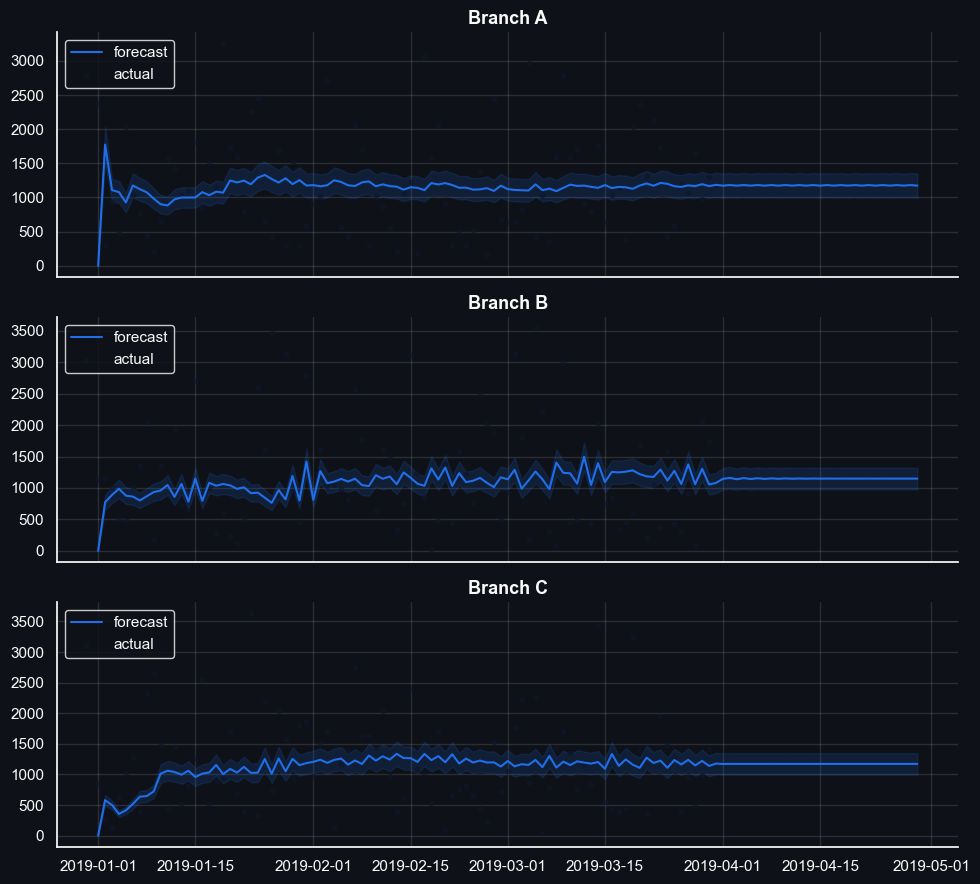

In [5]:
fc_all = pd.concat(forecasts, ignore_index=True)
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, branch in zip(axes, config.BRANCHES):
    sub = fc_all[fc_all['branch'] == branch]
    ax.plot(sub['ds'], sub['yhat'], color='#1f6feb', label='forecast')
    ax.fill_between(sub['ds'], sub['yhat_lower'], sub['yhat_upper'], color='#1f6feb', alpha=0.15)
    obs = daily[daily['Branch'] == branch]
    ax.scatter(obs['ds'], obs['y'], s=10, color='#0f172a', alpha=0.6, label='actual')
    ax.set_title(f'Branch {branch}')
    ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


## Persist forecasts and models


In [6]:
fc_all.to_parquet(config.FORECAST_PARQUET, index=False)
metrics.to_parquet(config.DATA_PROCESSED / 'forecast_metrics.parquet', index=False)
for branch, m in models_per_branch.items():
    try:
        joblib.dump(m, config.PROPHET_MODEL(branch))
    except Exception as e:
        print(f'could not pickle prophet model for {branch}:', e)
print('saved forecast and prophet models')


saved forecast and prophet models
